# ============================================================
# Notebook 04 : Feature Engineering & Machine Learning
# ============================================================

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [2]:
df = pd.read_csv("/content/cleaned_hotel_bookings.csv")

In [3]:
df["is_family"] = np.where(df["total_guests"] > 2, 1, 0)

season_map = {
    "December":"Winter","January":"Winter","February":"Winter",
    "March":"Spring","April":"Spring","May":"Spring",
    "June":"Summer","July":"Summer","August":"Summer",
    "September":"Autumn","October":"Autumn","November":"Autumn"
}

df["arrival_season"] = df["arrival_date_month"].map(season_map)

In [4]:
drop_cols = [

    "reservation_status",

    "reservation_status_date",

    "assigned_room_type",

    "booking_changes"

]

df_ml = df.drop(columns=drop_cols)

In [5]:
encoder = LabelEncoder()

for col in df_ml.select_dtypes(include="object").columns:
    df_ml[col] = encoder.fit_transform(df_ml[col])

In [6]:
X = df_ml.drop("is_canceled", axis=1)

y = df_ml["is_canceled"]

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42

)

In [7]:
lr = Pipeline([

    ("scaler", StandardScaler()),

    ("model", LogisticRegression(max_iter=3000))

])

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [8]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

In [9]:
rf = RandomForestClassifier(

    n_estimators=100,

    random_state=42

)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [10]:
results = pd.DataFrame({

    "Model":[

        "Logistic Regression",

        "Decision Tree",

        "Random Forest"

    ],

    "Accuracy":[

        accuracy_score(y_test, lr_pred),

        accuracy_score(y_test, dt_pred),

        accuracy_score(y_test, rf_pred)

    ],

    "Precision":[

        precision_score(y_test, lr_pred),

        precision_score(y_test, dt_pred),

        precision_score(y_test, rf_pred)

    ],

    "Recall":[

        recall_score(y_test, lr_pred),

        recall_score(y_test, dt_pred),

        recall_score(y_test, rf_pred)

    ],

    "F1 Score":[

        f1_score(y_test, lr_pred),

        f1_score(y_test, dt_pred),

        f1_score(y_test, rf_pred)

    ]

})

results.round(4)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.7677,0.6425,0.3263,0.4328
1,Decision Tree,0.7982,0.6283,0.6286,0.6285
2,Random Forest,0.8467,0.7584,0.6389,0.6936


# Model Comparison

Three machine learning models were trained to predict hotel booking cancellations.

Results:

- Logistic Regression achieved 76.77% accuracy.
- Decision Tree achieved 79.82% accuracy.
- Random Forest achieved the best performance with 84.67% accuracy and the highest F1 Score.

## Final Model

Random Forest was selected as the final model because it provides the best balance between precision and recall while maintaining the highest overall accuracy.

In [11]:
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":rf.feature_importances_

})

importance.sort_values(

    by="Importance",

    ascending=False

).head(15)

,Feature,Importance
1,lead_time,0.140061
12,country,0.105046
24,adr,0.094378
5,arrival_date_day_of_month,0.069971
4,arrival_date_week_number,0.060618
26,total_of_special_requests,0.060591
20,agent,0.059362
13,market_segment,0.046219
28,total_nights,0.041091
7,stays_in_week_nights,0.036671


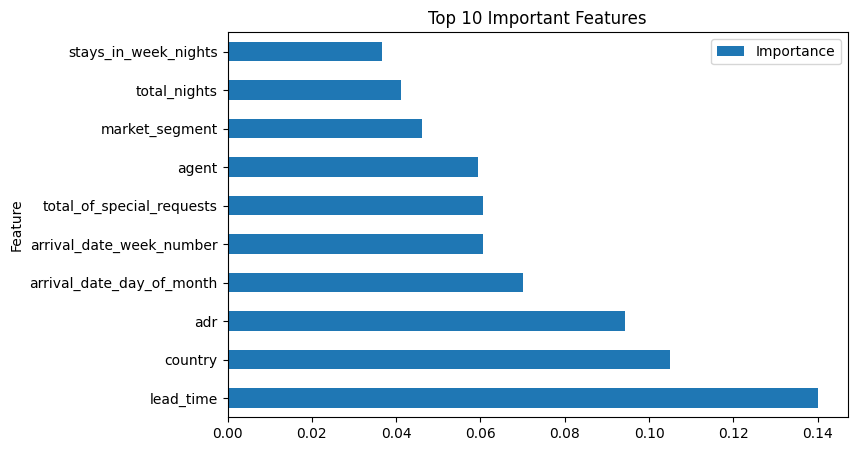

In [12]:
import matplotlib.pyplot as plt

top = importance.sort_values(
    by="Importance",
    ascending=False
).head(10)

top.plot(
    x="Feature",
    y="Importance",
    kind="barh",
    figsize=(8,5)
)

plt.title("Top 10 Important Features")
plt.show()

In [13]:
# Export Final Dataset

df.to_csv(
    "hotel_booking_final_dashboard.csv",
    index=False
)

print("Dashboard Dataset Ready ✅")

Dashboard Dataset Ready ✅


In [14]:
# ==========================
# Streamlit Deployment Pipeline
# ==========================

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import joblib

# Use leakage-free dataset
X_deploy = df_ml.drop("is_canceled", axis=1)
y_deploy = df_ml["is_canceled"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_deploy,
    y_deploy,
    test_size=0.2,
    random_state=42,
    stratify=y_deploy
)

# Identify columns
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X_train.select_dtypes(include=["object"]).columns

# Numeric preprocessing
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

# Categorical preprocessing
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# Pipeline
deployment_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=100,
            random_state=42
        ))
    ]
)

In [15]:
# Train Pipeline
deployment_pipeline.fit(X_train, y_train)

# Prediction
y_pred = deployment_pipeline.predict(X_test)

# Metrics
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

# Save Pipeline
joblib.dump(
    deployment_pipeline,
    "hotel_booking_pipeline.pkl"
)

print("\n✅ hotel_booking_pipeline.pkl saved successfully!")

Accuracy : 0.8451945080091533
Precision: 0.7570413911339701
Recall   : 0.6432882414151925
F1 Score : 0.6955445544554455

✅ hotel_booking_pipeline.pkl saved successfully!


In [16]:
import joblib

pipeline = joblib.load("hotel_booking_pipeline.pkl")

print(pipeline.feature_names_in_)

['hotel' 'lead_time' 'arrival_date_year' 'arrival_date_month'
 'arrival_date_week_number' 'arrival_date_day_of_month'
 'stays_in_weekend_nights' 'stays_in_week_nights' 'adults' 'children'
 'babies' 'meal' 'country' 'market_segment' 'distribution_channel'
 'is_repeated_guest' 'previous_cancellations'
 'previous_bookings_not_canceled' 'reserved_room_type' 'deposit_type'
 'agent' 'company' 'days_in_waiting_list' 'customer_type' 'adr'
 'required_car_parking_spaces' 'total_of_special_requests' 'total_guests'
 'total_nights' 'is_family' 'arrival_season']


In [24]:
joblib.dump(deployment_pipeline, "hotel_booking_pipeline.pkl", compress=8)


['hotel_booking_pipeline.pkl']

In [18]:
import sklearn
print(sklearn.__version__)


1.6.1


In [27]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier # Import the model

# 1. Numeric columns ke liye pipeline (Yahan median chalega)
numeric_features = ['lead_time', 'adr', 'total_of_special_requests'] # numeric columns ke naam
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

# 2. Categorical columns ke liye pipeline (Yahan 'most_frequent' use karein)
categorical_features = ['hotel', 'meal', 'customer_type'] # text columns ke naam
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), # Text ke liye safe hai
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# 3. Dono ko ColumnTransformer mein combine karein
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Define the model (for example, RandomForestClassifier as used in `deployment_pipeline`)
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Final Pipeline
pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                           ('model', model)])